In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(1, '../')

# 09 Operational Deflection Shapes (ODS)
Description

In [14]:
import pyFBS

import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

Open 3Dviewer in the background.

In [4]:
view3D = pyFBS.view3D()

Add a structure from STL file to the 3D 

In [5]:
stl = pyFBS.example_auto_testbench["STL"]["receiver"]
_ = view3D.add_stl(stl,name = "83afd2",color = "#e0e0e0",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["transmission_mount"]
_ = view3D.add_stl(stl,name = "transmission_mount",color = "#83afd2",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["roll_mount"]
_ = view3D.add_stl(stl,name = "roll_mount",color = "#83afd2",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["engine_mount"]
_ = view3D.add_stl(stl,name = "engine_mount",color = "#83afd2",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["ts"]
_ = view3D.add_stl(stl,name = "ts",color = "#d62728",opacity = .1)

stl = pyFBS.example_auto_testbench["STL"]["shaker_only"]
_ = view3D.add_stl(stl,name = "shaker_only",color = "#f0adad",opacity = .1)

Add accelerometers from .xlsx file together with appropriate labels

In [6]:
pos_xlsx = pyFBS.example_auto_testbench["meas"]["xlsx_ODS"]
df_acc = pd.read_excel(pos_xlsx, sheet_name='Sensors')

view3D.show_acc(df_acc)
#view3D.label_acc(df)

Load channels

In [7]:
df_chn = pd.read_excel(pos_xlsx, sheet_name='Channels')

Add impacts 

In [9]:
df_imp = pd.read_excel(pos_xlsx, sheet_name='Impacts')

view3D.show_imp(df_imp)
view3D.label_imp(df_imp)

### Experimental data
Load the data

In [12]:
_file = pyFBS.example_auto_testbench["meas"]["Y_ODS"]
freq, Y_ODS = np.load(_file,allow_pickle = True)

Display the FRFs

,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
5,S2z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,0.01,0.025,0.0,0.0,1.0


,Name,Description,Type,DirectionLabel,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
1,H2,NaN,NaN,-X,NaN,NaN,NaN,NaN,NaN,0.4,0.01,0.31,-1,0,0


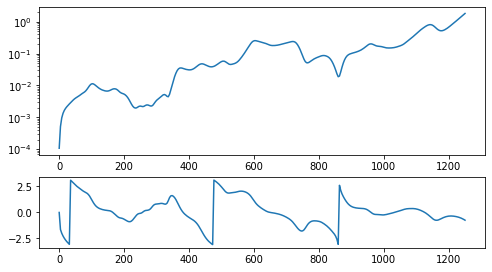

In [16]:
select_out = 5
select_in = 1

display(df_chn.iloc[[select_out]])
display(df_imp.iloc[[select_in]])

plt.figure(figsize = (8,6))
plt.subplot(211)
plt.semilogy(freq,np.abs(Y_ODS[:,select_out,select_in]))

plt.subplot(413)
plt.plot(freq,np.angle(Y_ODS[:,select_out,select_in]))

## Object animation (accelerometers)
Description

In [17]:
freq_sel = -1
select_in = 6

n_sen = n_sen = len(df_acc)
n_ax = 3 

empty = np.zeros((n_sen,n_ax),dtype = complex)

_dir = df_chn[["Direction_1","Direction_2","Direction_3"]].to_numpy()
for i in range(n_sen):
    for j in range(n_ax):
        sel = (i)*3+j
        empty[i,:] += _dir[sel:sel+1,:].T@np.asarray([Y_ODS[freq_sel,sel,select_in]])
        

mode_dict = dict_animation(empty,"object",object_list = view3D.global_acc,r_scale=30)
mode_dict["freq"] = freq[freq_sel]
view3D.add_objects_animation(mode_dict,run_animation = True,add_note= True)

NameError: name 'dict_animation' is not defined